# 🔍 Fraud Detection Pipeline
## Phát hiện giao dịch gian lận trong thương mại điện tử

### Mô tả bài toán
- **Dataset**: 300,000 giao dịch thương mại điện tử
- **Mục tiêu**: Phân loại giao dịch gian lận (`Is Fraudulent = 1`)
- **Thách thức**: Dataset mất cân bằng nghiêm trọng (~5% fraud)

### Metric đánh giá chính
| Metric | Lý do chọn |
|--------|-----------|
| **F2-score** | Metric chính — penalize việc bỏ sót fraud nặng hơn false alarm |
| **PR-AUC** | Đánh giá tổng thể khả năng phân biệt fraud trên mọi threshold |
| **Recall** | Tỷ lệ fraud thực sự bị phát hiện |

> ⚠️ Trong fraud detection, **bỏ sót một giao dịch gian lận** tốn kém hơn nhiều so với **cảnh báo nhầm** một giao dịch hợp lệ. Do đó F2-score (weight recall gấp đôi precision) là metric phù hợp nhất.

### Pipeline tổng quan
```
Load Data → EDA → Feature Engineering → Train/Test Split
→ Group Statistics → Pattern Features
→ Spark MLlib: LR + RF + GBT → Chọn Best Model (F2)
→ Threshold Tuning (F2) → Final Evaluation
```

In [ ]:
# ═══════════════════════════════════════════════
# CELL 2: Install & Import
# ═══════════════════════════════════════════════
!pip install -q pyspark scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Sklearn (chỉ dùng cho metrics & split)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, precision_recall_curve,
    roc_auc_score, f1_score, fbeta_score, precision_score, recall_score
)

# PySpark
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.feature import (
    VectorAssembler, StandardScaler as SparkScaler,
    StringIndexer, OneHotEncoder as SparkOHE
)
from pyspark.ml.classification import (
    LogisticRegression as SparkLR,
    RandomForestClassifier as SparkRF,
    GBTClassifier
)
from pyspark.sql.functions import col, when, udf
from pyspark.sql.types import FloatType
from pyspark import StorageLevel
import time

TARGET_COL = "Is Fraudulent"
DATE_COL   = "Transaction Date"
plt.style.use("seaborn-v0_8-whitegrid")

print("✅ Done")

## Bước 1: Load & Khám phá dữ liệu (EDA)

### Các vấn đề phát hiện từ EDA
1. **Mixed datetime format** → dùng `format='mixed'`
2. **High-cardinality features** (`IP Address`, `Customer Location`) → leakage nghiêm trọng (train corr=0.99, test corr=0.006) → **DROP hoàn toàn**
3. **Customer Age** có giá trị < 18 → clean bằng median của train

### Fraud patterns phát hiện
| Feature | Fraud Rate | Lift |
|---------|-----------|------|
| Giờ 0–5 sáng | 10.4% | 2.1x |
| Account Age 0–30 ngày | **22.2%** | **4.4x** |
| Amount top 20% | 10.3% | 2.1x |
| New + Night + High Amount | **58.2%** | **11.6x** |
| Address mismatch | ~5.0% | ~1.0x *(không có signal)* |

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


✅ Loaded : 300,000 rows × 16 columns
📅 Range  : 2024-01-29 → 2024-02-17
⚖️  Fraud  : 5.00%  (imbalance ratio 1:19)


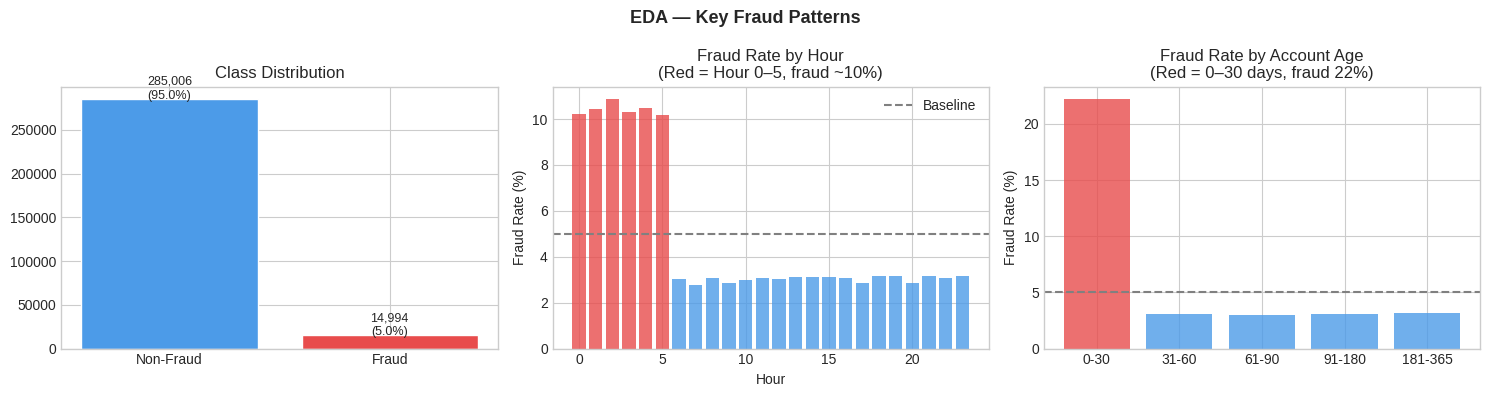

In [14]:
# ═══════════════════════════════════════════════
# CELL 4: Load Data & EDA
# ═══════════════════════════════════════════════
df = pd.read_csv("/content/drive/MyDrive/fraud_300k_raw_temporal.csv")
df[DATE_COL] = pd.to_datetime(df[DATE_COL], format="mixed", dayfirst=False)

print(f"✅ Loaded : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📅 Range  : {df[DATE_COL].min().date()} → {df[DATE_COL].max().date()}")
print(f"⚖️  Fraud  : {df[TARGET_COL].mean()*100:.2f}%  "
      f"(imbalance ratio 1:{int((1-df[TARGET_COL].mean())/df[TARGET_COL].mean())})")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("EDA — Key Fraud Patterns", fontsize=13, fontweight="bold")

# 1. Class imbalance
counts = df[TARGET_COL].value_counts()
axes[0].bar(["Non-Fraud", "Fraud"], counts.values,
            color=["#4C9BE8", "#E84C4C"], edgecolor="white")
axes[0].set_title("Class Distribution")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f"{v:,}\n({v/len(df)*100:.1f}%)",
                 ha="center", fontsize=9)

# 2. Fraud rate by hour
hour_fraud = df.groupby("Transaction Hour")[TARGET_COL].mean() * 100
axes[1].bar(hour_fraud.index, hour_fraud.values,
            color=["#E84C4C" if h <= 5 else "#4C9BE8"
                   for h in hour_fraud.index], alpha=0.8)
axes[1].set_title("Fraud Rate by Hour\n(Red = Hour 0–5, fraud ~10%)")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].axhline(df[TARGET_COL].mean()*100, color="gray",
                linestyle="--", label="Baseline")
axes[1].legend()

# 3. Fraud rate by Account Age bucket
df_tmp = df.copy()
df_tmp["age_bucket"] = pd.cut(df_tmp["Account Age Days"],
                               bins=[0,30,60,90,180,365,999],
                               labels=["0-30","31-60","61-90","91-180","181-365","365+"])
age_fraud = df_tmp.groupby("age_bucket")[TARGET_COL].mean() * 100
axes[2].bar(age_fraud.index, age_fraud.values,
            color=["#E84C4C" if i == 0 else "#4C9BE8"
                   for i in range(len(age_fraud))], alpha=0.8)
axes[2].set_title("Fraud Rate by Account Age\n(Red = 0–30 days, fraud 22%)")
axes[2].set_ylabel("Fraud Rate (%)")
axes[2].axhline(df[TARGET_COL].mean()*100, color="gray", linestyle="--")

plt.tight_layout()
plt.show()

## Bước 2: Feature Engineering

### Nguyên tắc chống Data Leakage
- **DROP** cột định danh: `Transaction ID`, `Customer ID`, `IP Address`, `Customer Location`
- Mọi threshold (Q25, Q80, median) **fit chỉ trên train set**
- Scaler/Encoder nằm trong `ColumnTransformer` — chỉ fit trên train

### Features được tạo
| Feature | Loại | Mô tả |
|---------|------|-------|
| `is_night` | Binary | Giờ 0–5 → fraud rate 2.1x |
| `amount_log` | Numerical | Log transform giảm skewness |
| `is_very_new_account` | Binary | Account age ≤ 30 ngày → 22% fraud |
| `is_high_amount` | Binary | Amount top 20% → fraud rate 2x |
| `new_x_night` | Interaction | New account × night |
| `new_x_highamount` | Interaction | New × high amount → 38% fraud |
| `new_night_highamount` | Interaction | New × night × high amount → **58% fraud** |
| `account_age_clipped` | Numerical | Account age clip 0–60 ngày |
| `*_fraud_rate` | Statistical | Smoothed fraud rate theo Payment/Category/Device |

In [15]:
# ═══════════════════════════════════════════════
# CELL 6: Feature Engineering (row-level, không leakage)
# ═══════════════════════════════════════════════
def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["address_mismatch"] = (
        df["Shipping Address"].str.strip() != df["Billing Address"].str.strip()
    ).astype(int)
    df["is_night"]         = (df["Transaction Hour"] <= 5).astype(int)
    df["amount_log"]       = np.log1p(df["Transaction Amount"])
    df["amount_per_qty"]   = df["Transaction Amount"] / df["Quantity"].replace(0, 1)
    df["account_age_days"] = df["Account Age Days"]
    df["customer_age"]     = df["Customer Age"].clip(lower=10)
    df["tx_hour"]          = df[DATE_COL].dt.hour
    df["tx_dayofweek"]     = df[DATE_COL].dt.dayofweek
    return df

df = feature_engineering(df)
print("✅ Base features created")

✅ Base features created


## Bước 3: Train/Test Split (Stratified)

Dùng `stratify=y` để đảm bảo tỷ lệ fraud **giống nhau** trong train và test.  
Mọi threshold và statistics được tính **chỉ trên train set** sau bước này để tránh data leakage.

In [16]:
# ═══════════════════════════════════════════════
# CELL 8: Split → Fix Anomaly → Group Stats → Pattern Features
# ═══════════════════════════════════════════════

# DROP identifier & leaky columns
DROP_COLS = [
    "Transaction ID", "Customer ID", DATE_COL,
    "IP Address", "Customer Location",
    "Shipping Address", "Billing Address",
    "Customer Age", "Account Age Days",
    "Transaction Hour", "Transaction Amount",
]
DROP_COLS = [c for c in DROP_COLS if c in df.columns]

X = df.drop(columns=DROP_COLS + [TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"✅ Split: Train={len(X_train):,} | Test={len(X_test):,}")
print(f"   Fraud — Train: {y_train.mean()*100:.2f}% | Test: {y_test.mean()*100:.2f}%")

# Fix Customer Age (median từ train)
age_median = X_train["customer_age"][X_train["customer_age"] >= 18].median()
for df_ in [X_train, X_test]:
    df_["customer_age"] = df_["customer_age"].apply(
        lambda x: age_median if x < 18 else x)
print(f"\n✅ Customer age median (train): {age_median}")

# Group Statistics (fit ONLY on train)
train_tmp   = X_train.copy()
train_tmp["__label__"] = y_train.values
global_mean = y_train.mean()

for col_name in ["Payment Method", "Product Category", "Device Used"]:
    stats = (train_tmp.groupby(col_name)["__label__"]
             .agg(["mean", "count"])
             .rename(columns={"mean": "fraud_rate", "count": "n"}))
    smoothing = 20
    stats["smoothed"] = (
        (stats["n"] * stats["fraud_rate"] + smoothing * global_mean)
        / (stats["n"] + smoothing)
    )
    feat_name  = col_name.lower().replace(" ", "_") + "_fraud_rate"
    encode_map = stats["smoothed"].to_dict()
    X_train[feat_name] = X_train[col_name].map(encode_map).fillna(global_mean)
    X_test[feat_name]  = X_test[col_name].map(encode_map).fillna(global_mean)

cat_amount_mean = train_tmp.groupby("Product Category")["amount_log"].mean().to_dict()
cat_qty_mean    = train_tmp.groupby("Product Category")["Quantity"].mean().to_dict()
for df_ in [X_train, X_test]:
    df_["amount_vs_category"] = (df_["amount_log"] -
                                  df_["Product Category"].map(cat_amount_mean).fillna(0))
    df_["qty_vs_category"]    = (df_["Quantity"] -
                                  df_["Product Category"].map(cat_qty_mean).fillna(0))
print("✅ Group statistics features created")

# Pattern Features (threshold từ train)
amt_q80       = X_train["amount_log"].quantile(0.80)
age_q25_train = X_train["account_age_days"].quantile(0.25)

for df_ in [X_train, X_test]:
    df_["is_new_account"]      = (df_["account_age_days"] <= age_q25_train).astype(int)
    df_["is_very_new_account"] = (df_["account_age_days"] <= 30).astype(int)
    df_["account_age_clipped"] = df_["account_age_days"].clip(upper=60)
    df_["is_high_amount"]      = (df_["amount_log"] >= amt_q80).astype(int)
    df_["new_x_night"]         = df_["is_new_account"]     * df_["is_night"]
    df_["amount_x_night"]      = df_["amount_log"]          * df_["is_night"]
    df_["amount_x_very_new"]   = df_["amount_log"]          * df_["is_very_new_account"]
    df_["mismatch_x_amount"]   = df_["address_mismatch"]    * df_["amount_log"]
    df_["new_x_highamount"]    = df_["is_very_new_account"] * df_["is_high_amount"]
    df_["new_night_highamount"]= (df_["is_very_new_account"] *
                                  df_["is_night"] * df_["is_high_amount"])
print("✅ Pattern features created")

# Verify
tmp = X_train.copy()
tmp["label"] = y_train.values
print(f"\n📊 Signal verification (train):")
print(f"   is_very_new_account=1  : "
      f"{tmp[tmp['is_very_new_account']==1]['label'].mean()*100:.1f}% fraud")
print(f"   new_x_highamount=1     : "
      f"{tmp[tmp['new_x_highamount']==1]['label'].mean()*100:.1f}% fraud")
print(f"   new_night_highamount=1 : "
      f"{tmp[tmp['new_night_highamount']==1]['label'].mean()*100:.1f}% fraud  ← strongest signal")

✅ Split: Train=240,000 | Test=60,000
   Fraud — Train: 5.00% | Test: 5.00%

✅ Customer age median (train): 35.0
✅ Group statistics features created
✅ Pattern features created

📊 Signal verification (train):
   is_very_new_account=1  : 22.1% fraud
   new_x_highamount=1     : 38.2% fraud
   new_night_highamount=1 : 58.2% fraud  ← strongest signal


## Bước 4: Huấn luyện & So sánh Models

### Chiến lược
Sử dụng **Apache Spark MLlib** để huấn luyện 3 model phân tán, sau đó **tự động chọn model tốt nhất** theo F2-score.

| Model | Đặc điểm |
|-------|----------|
| Logistic Regression | Baseline tuyến tính, dễ giải thích, coefficients có ý nghĩa rõ ràng |
| Random Forest | Ensemble, ổn định với imbalanced data, featureImportances (Gini) |
| GBT (Gradient Boosted Trees) | Boosting phân tán, thường mạnh nhất, featureImportances (variance reduction) |

### Xử lý Class Imbalance
- **Tất cả 3 models** đều dùng `weightCol` với weight = count(0)/count(1) ≈ 19


In [ ]:
# ═══════════════════════════════════════════════
# CELL 10: Spark MLlib — SAFE Optimization + Train 3 Models
# ═══════════════════════════════════════════════

# Mục tiêu của cell này:
# - GIỮ NGUYÊN logic ML của Pipeline_BigData (1): same split, same features,
#   same base_stages, same model params, same threshold tuning sau đó.
# - CHỈ thêm tối ưu tầng Spark execution: persist/cache, materialize cache,
#   explain physical plan, và log thời gian chạy.
# - KHÔNG dùng repartition() ở đây để tránh đổi thứ tự dòng test khi toPandas(),
#   từ đó tránh lệch y_prob với y_test ở các cell đánh giá phía sau.
# - KHÔNG fit preprocessing riêng một lần vì mục tiêu là giữ hành vi pipeline gốc.

# ── Khởi tạo SparkSession: giữ config gần như code gốc ──
spark = SparkSession.builder \
    .appName("FraudDetection_MLlib_Optimized_SAFE") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"✅ Spark {spark.version} | Master: {spark.sparkContext.master}")

# ── Helper đo thời gian ──
perf_log = []

def timed_count(df_spark, name: str) -> int:
    """Action count() để Spark chạy thật và materialize cache/persist."""
    t0 = time.perf_counter()
    n = df_spark.count()
    sec = time.perf_counter() - t0
    perf_log.append({"step": name, "rows": n, "seconds": sec})
    print(f"✅ {name}: {n:,} rows | {sec:.2f}s")
    return n

def timed_fit_pipeline(pipeline, dataset, name: str):
    """Fit pipeline y như code gốc, chỉ bọc thêm timer."""
    t0 = time.perf_counter()
    fitted = pipeline.fit(dataset)
    sec = time.perf_counter() - t0
    perf_log.append({"step": f"train_{name}", "rows": n_train, "seconds": sec})
    print(f"   ✅ Done | {sec:.2f}s")
    return fitted

# ── Chuyển sang Spark DataFrame: giữ nguyên dữ liệu đầu vào như code gốc ──
train_pd = X_train.copy()
train_pd["label"] = y_train.values
test_pd  = X_test.copy()
test_pd["label"]  = y_test.values

train_spark = spark.createDataFrame(train_pd)
test_spark  = spark.createDataFrame(test_pd)

# ── SAFE persist/cache: không đổi dữ liệu, không đổi model logic ──
# MEMORY_AND_DISK an toàn hơn cache() mặc định khi RAM không đủ.
train_spark = train_spark.persist(StorageLevel.MEMORY_AND_DISK)
test_spark  = test_spark.persist(StorageLevel.MEMORY_AND_DISK)

n_train = timed_count(train_spark, "materialize_train_spark_persist")
n_test  = timed_count(test_spark,  "materialize_test_spark_persist")
print(f"✅ Spark DataFrames: train={n_train:,} | test={n_test:,}")

print("\n🔍 EXPLAIN PLAN — train_spark sau persist()")
train_spark.explain(True)

# ── Feature columns cho Spark: giữ nguyên code gốc ──
SPARK_NUM = [
    "amount_log", "account_age_clipped", "tx_hour",
    "amount_x_very_new", "amount_vs_category", "qty_vs_category",
    "payment_method_fraud_rate", "product_category_fraud_rate",
    "device_used_fraud_rate",
]
SPARK_BIN = [
    "is_night", "is_very_new_account", "is_high_amount",
    "new_x_night", "new_night_highamount", "new_x_highamount",
]
SPARK_CAT = ["Payment Method", "Product Category", "Device Used"]

SPARK_NUM = [c for c in SPARK_NUM if c in train_pd.columns]
SPARK_BIN = [c for c in SPARK_BIN if c in train_pd.columns]
SPARK_CAT = [c for c in SPARK_CAT if c in train_pd.columns]

# ── Class weight cho imbalance: giữ nguyên công thức code gốc ──
neg_n = train_spark.filter(col("label") == 0).count()
pos_n = train_spark.filter(col("label") == 1).count()
w_pos = float(neg_n / pos_n)

train_spark_w = train_spark.withColumn(
    "classWeight",
    when(col("label") == 1, w_pos).otherwise(1.0)
).persist(StorageLevel.MEMORY_AND_DISK)

timed_count(train_spark_w, "materialize_train_spark_w_persist")
print(f"⚖️  scale_pos_weight = {w_pos:.2f}  (áp dụng cho LR, RF, GBT)")

print("\n🔍 EXPLAIN PLAN — train_spark_w sau thêm classWeight + persist()")
train_spark_w.explain(True)

# ── Spark Pipeline stages: GIỮ NGUYÊN như Pipeline_BigData (1) ──
indexers  = [StringIndexer(inputCol=c, outputCol=f"{c}_idx",
                            handleInvalid="keep") for c in SPARK_CAT]
encoders  = [SparkOHE(inputCol=f"{c}_idx", outputCol=f"{c}_ohe",
                       handleInvalid="keep") for c in SPARK_CAT]
ohe_cols  = [f"{c}_ohe" for c in SPARK_CAT]

assembler = VectorAssembler(
    inputCols=SPARK_NUM + SPARK_BIN + ohe_cols,
    outputCol="features_raw", handleInvalid="keep"
)
scaler = SparkScaler(
    inputCol="features_raw", outputCol="features",
    withMean=True, withStd=True
)
base_stages = indexers + encoders + [assembler, scaler]

# ── Define 3 models: GIỮ NGUYÊN params code gốc ──
lr_clf = SparkLR(
    featuresCol="features", labelCol="label",
    weightCol="classWeight",
    maxIter=100, regParam=0.01, elasticNetParam=0.5
)
rf_clf = SparkRF(
    featuresCol="features", labelCol="label",
    weightCol="classWeight",
    numTrees=100, maxDepth=5, seed=42
)
gbt_clf = GBTClassifier(
    featuresCol="features", labelCol="label",
    weightCol="classWeight",
    maxIter=50, maxDepth=4, stepSize=0.05, seed=42
)

# ── Train: GIỮ NGUYÊN cách fit SparkPipeline(base_stages + model) ──
print("\n🔄 Training Logistic Regression (Spark MLlib)...")
fitted_lr  = timed_fit_pipeline(SparkPipeline(stages=base_stages + [lr_clf]),
                                train_spark_w, "Logistic Regression")

print("🔄 Training Random Forest (Spark MLlib)...")
fitted_rf  = timed_fit_pipeline(SparkPipeline(stages=base_stages + [rf_clf]),
                                train_spark_w, "Random Forest")

print("🔄 Training GBT (Spark MLlib)...")
fitted_gbt = timed_fit_pipeline(SparkPipeline(stages=base_stages + [gbt_clf]),
                                train_spark_w, "GBT")

# ── Bảng log hiệu năng để chụp màn hình đưa vào báo cáo ──
perf_df = pd.DataFrame(perf_log)
print("\n📌 DISTRIBUTED PERFORMANCE LOG — dùng cho mục tối ưu hiệu năng phân tán")
display(perf_df)

print("""
✅ SAFE OPTIMIZATION ĐÃ ÁP DỤNG:
  - persist(StorageLevel.MEMORY_AND_DISK) cho train_spark, test_spark, train_spark_w
  - materialize persist bằng count()
  - explain(True) để minh chứng logical/physical plan
  - đo thời gian count() và fit() từng model
  - KHÔNG đổi feature engineering / split / model params / threshold logic
  - KHÔNG repartition() để tránh lệch thứ tự dòng khi đánh giá
""")

In [ ]:
# ═══════════════════════════════════════════════
# CELL 12: Evaluate 3 Spark Models & Chọn Best
# ═══════════════════════════════════════════════
from pyspark.ml.classification import (
    RandomForestClassificationModel,
    GBTClassificationModel,
    LogisticRegressionModel
)

# ── Helper: lấy probability từ Spark pipeline ──
def get_spark_prob(fitted_pipeline, test_spark):
    get_p1 = udf(lambda v: float(v[1]), FloatType())
    preds  = fitted_pipeline.transform(test_spark)
    pdf    = preds.select("label",
                           get_p1(col("probability")).alias("prob")) \
                  .toPandas()
    return pdf["label"].values, pdf["prob"].values

# ── Helper: evaluate + threshold tuning ──
def get_metrics(y_true, y_prob, model_name):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    pr_auc  = average_precision_score(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    best_t, best_f2 = 0.5, 0
    for t in np.arange(0.1, 0.9, 0.01):
        f2 = fbeta_score(y_true, (y_prob >= t).astype(int),
                         beta=2, zero_division=0)
        if f2 > best_f2:
            best_f2, best_t = f2, t
    y_pred    = (y_prob >= best_t).astype(int)
    recall    = (y_pred[y_true == 1] == 1).mean()
    precision = (y_true[y_pred == 1] == 1).mean() \
                if y_pred.sum() > 0 else 0
    return {"Model": model_name,
            "PR-AUC": pr_auc, "ROC-AUC": roc_auc,
            "F2-score": best_f2, "Recall": recall,
            "Precision": precision, "Best Threshold": best_t}

# ── Evaluate 3 models ──
print("📊 Evaluating all models...")
y_true_lr,  y_prob_lr  = get_spark_prob(fitted_lr,  test_spark)
y_true_rf,  y_prob_rf  = get_spark_prob(fitted_rf,  test_spark)
y_true_gbt, y_prob_gbt = get_spark_prob(fitted_gbt, test_spark)

all_results = [
    get_metrics(y_true_lr,  y_prob_lr,  "Logistic Regression"),
    get_metrics(y_true_rf,  y_prob_rf,  "Random Forest"),
    get_metrics(y_true_gbt, y_prob_gbt, "GBT"),
]

# ── Chọn best model theo F2-score ──
best_result     = max(all_results, key=lambda x: x["F2-score"])
best_model_name = best_result["Model"]
best_threshold  = best_result["Best Threshold"]

# Lưu y_eval đi cùng y_prob để các cell sau KHÔNG bị lệch thứ tự dòng.
# Đây là điểm sửa quan trọng so với bản optimized bị lỗi Recall=1 / ROC-AUC≈0.5.
model_map = {
    "Logistic Regression": (fitted_lr,  y_true_lr,  y_prob_lr),
    "Random Forest":       (fitted_rf,  y_true_rf,  y_prob_rf),
    "GBT":                 (fitted_gbt, y_true_gbt, y_prob_gbt),
}
fitted_best, y_eval, y_prob = model_map[best_model_name]
y_eval = np.array(y_eval)
y_prob = np.array(y_prob)

# ── Lấy feature importance TRƯỚC khi stop Spark ──
model_stage = fitted_best.stages[-1]

if isinstance(model_stage, (RandomForestClassificationModel,
                             GBTClassificationModel)):
    importances_array = np.array(model_stage.featureImportances.toArray())
    imp_label   = "Feature Importance"
    method_note = ("Gini impurity" if isinstance(model_stage, RandomForestClassificationModel)
                   else "Variance reduction (như XGBoost gain)")
elif isinstance(model_stage, LogisticRegressionModel):
    importances_array = np.abs(np.array(model_stage.coefficients.toArray()))
    importances_array = importances_array / importances_array.sum()
    imp_label   = "Abs. Coefficient (normalized)"
    method_note = "Absolute value of scaled coefficients"

print(f"✅ Feature importances extracted ({len(importances_array)} features)")

print("\n🔍 EXPLAIN PLAN — best_model.transform(test_spark)")
fitted_best.transform(test_spark).select("label", "probability", "prediction").explain(True)

# ── Giải phóng cache/persist sau khi đã lấy đủ kết quả ──
for _df in [train_spark, test_spark, train_spark_w]:
    try:
        _df.unpersist()
    except Exception:
        pass

# ── Stop Spark ──
spark.stop()
print("✅ Spark session stopped")

# ── Bảng so sánh ──
compare_df = (pd.DataFrame(all_results)
              .set_index("Model")
              .sort_values("F2-score", ascending=False))

print(f"\n{'='*60}")
print("📊 MODEL COMPARISON — sorted by F2-score (metric chính)")
print(f"{'='*60}")
display(compare_df[["PR-AUC","ROC-AUC","F2-score","Recall","Precision"]]
        .round(4)
        .style
        .background_gradient(cmap="RdYlGn",
                             subset=["PR-AUC","F2-score","Recall"])
        .highlight_max(subset=["F2-score","PR-AUC","Recall"],
                       color="#90EE90"))

# ── Bar chart so sánh ──
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Model Comparison — Spark MLlib (LR / RF / GBT)",
             fontsize=13, fontweight="bold")

model_names = [r["Model"] for r in all_results]
bar_colors  = ["#E84C4C" if r["Model"] == best_model_name
               else "#4C9BE8" for r in all_results]

for ax, metric in zip(axes, ["PR-AUC", "F2-score", "Recall"]):
    vals = [r[metric] for r in all_results]
    bars = ax.bar(model_names, vals,
                  color=bar_colors, alpha=0.85, edgecolor="white")
    ax.set_title(metric, fontweight="bold")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=15, labelsize=8)
    ax.set_ylim([0, max(vals) * 1.18])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{v:.3f}", ha="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"""
🏆 MODEL ĐƯỢC CHỌN: {best_model_name}
{'='*50}
  ✅ F2-score cao nhất  : {best_result['F2-score']:.4f}
  ✅ PR-AUC             : {best_result['PR-AUC']:.4f}
  ✅ Recall             : {best_result['Recall']:.4f}
  ✅ Threshold (tuned)  : {best_threshold:.2f}
  ✅ weightCol          : xử lý imbalance không cần SMOTE
{'='*50}
""")

## Bước 5: Feature Importance

Phân tích feature importance của **model được chọn** để xác nhận model học đúng các fraud patterns đã phát hiện từ EDA.

| Model được chọn | Phương pháp |
|-----------------|-------------|
| Random Forest | `featureImportances` — Gini impurity (mean decrease impurity) |
| GBT | `featureImportances` — variance reduction (tương tự XGBoost gain) |
| Logistic Regression | Absolute value of coefficients (sau khi scale) |

all_features  : 24
importances   : 30
⚠️  Lệch 6 — dùng generic names cho phần dư

🏆 Top 15 Feature Importances — GBT
   Method: Variance reduction (như XGBoost gain)


,Feature,Importance
1,tx_hour,0.325855
2,is_night,0.203745
3,amount_x_very_new,0.157439
4,amount_vs_category,0.144167
5,amount_log,0.129168
6,account_age_clipped,0.027585
7,qty_vs_category,0.004994
8,product_category_fraud_rate,0.003474
9,new_x_highamount,0.001162
10,payment_method_fraud_rate,0.001100


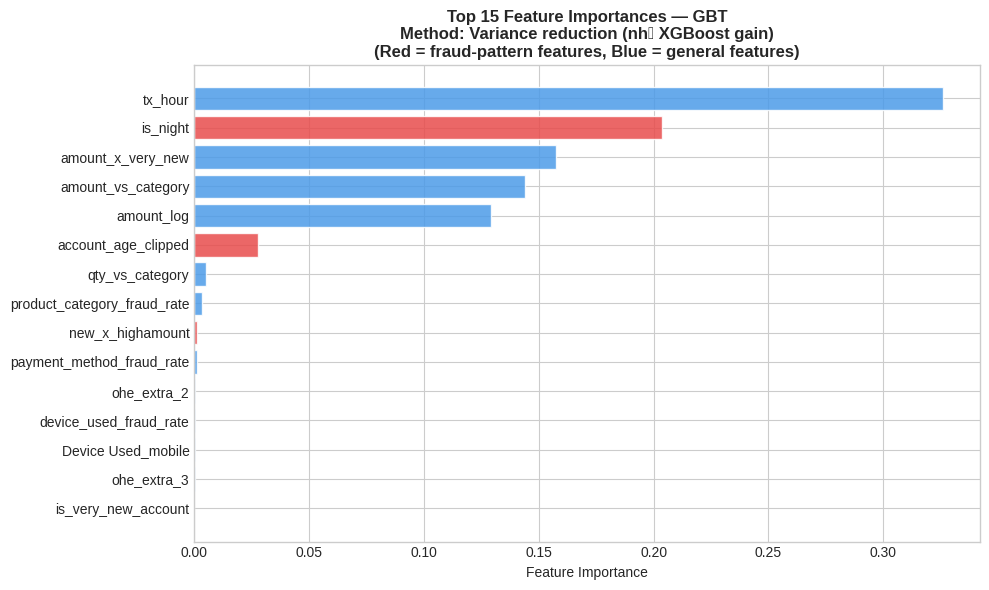

In [19]:
# ═══════════════════════════════════════════════
# CELL 14: Feature Importance — Best Model
# ═══════════════════════════════════════════════

# ── Tính ohe_names từ data thay vì từ Spark stages ──
ohe_names = []
for col_base in SPARK_CAT:
    # Lấy unique categories từ train data (đã có sẵn trong X_train)
    cats = sorted(X_train[col_base].dropna().unique())
    # Spark OHE drop last category theo mặc định
    ohe_names += [f"{col_base}_{c}" for c in cats[:-1]]

all_feature_names = SPARK_NUM + SPARK_BIN + ohe_names

# ── Kiểm tra độ dài ──
print(f"all_features  : {len(all_feature_names)}")
print(f"importances   : {len(importances_array)}")

# Nếu vẫn lệch, pad hoặc trim tên cho khớp
if len(all_feature_names) != len(importances_array):
    print(f"⚠️  Lệch {len(importances_array) - len(all_feature_names)} — dùng generic names cho phần dư")
    extra = len(importances_array) - len(all_feature_names)
    all_feature_names += [f"ohe_extra_{i}" for i in range(extra)]

# ── Dùng importances_array đã extract từ Cell 12 ──
imp_df = pd.DataFrame({
    "Feature"   : all_feature_names[:len(importances_array)],
    "Importance": importances_array
}).sort_values("Importance", ascending=False).reset_index(drop=True)
imp_df.index += 1

print(f"\n🏆 Top 15 Feature Importances — {best_model_name}")
print(f"   Method: {method_note}")
display(imp_df.head(15).style.bar(subset=["Importance"], color="#E84C4C"))

plt.figure(figsize=(10, 6))
top15  = imp_df.head(15)
colors = ["#E84C4C" if f in ["new_night_highamount", "is_very_new_account",
                               "new_x_highamount", "is_night", "new_x_night",
                               "account_age_clipped"]
          else "#4C9BE8" for f in top15["Feature"]]
plt.barh(top15["Feature"][::-1], top15["Importance"][::-1],
         color=colors[::-1], alpha=0.85, edgecolor="white")
plt.xlabel(imp_label)
plt.title(f"Top 15 Feature Importances — {best_model_name}\n"
          f"Method: {method_note}\n"
          "(Red = fraud-pattern features, Blue = general features)",
          fontweight="bold")
plt.tight_layout()
plt.show()

## Bước 7: Threshold Tuning (F2-optimized)

### Tại sao không dùng threshold mặc định 0.5?
Với imbalance ~5%, model output probability thấp cho fraud → threshold 0.5 bỏ sót hầu hết fraud.

### F2-score
$$F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \times \text{Recall}}{(\beta^2 \times \text{Precision}) + \text{Recall}}$$

Với $\beta = 2$: **Recall được weight gấp đôi Precision.**

In [ ]:
# ═══════════════════════════════════════════════
# CELL 16: Threshold Tuning — Tối ưu F2-score
# ═══════════════════════════════════════════════
# Dùng y_eval lấy trực tiếp từ Spark predictions để bảo đảm cùng thứ tự với y_prob.
# Không dùng y_test ở cell này vì nếu Spark thay đổi thứ tự dòng khi toPandas(),
# y_test có thể lệch với y_prob và làm ROC-AUC / Recall / Precision sai.

thresholds    = np.arange(0.10, 0.90, 0.01)
thr_results   = []
best_t, best_f2 = best_threshold, 0

y_eval = np.array(y_eval)
y_prob = np.array(y_prob)

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    f2   = fbeta_score(y_eval, y_pred, beta=2, zero_division=0)
    f1   = f1_score(y_eval, y_pred, zero_division=0)
    precision = precision_score(y_eval, y_pred, zero_division=0)
    recall    = recall_score(y_eval, y_pred, zero_division=0)
    thr_results.append({"threshold": t, "f2": f2, "f1": f1,
                        "precision": precision, "recall": recall})
    if f2 > best_f2:
        best_f2, best_t = f2, t

thr_df = pd.DataFrame(thr_results)
print(f"🎯 Best threshold : {best_t:.2f}  |  F2 = {best_f2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"Threshold Tuning — {best_model_name} (F2-optimized)",
             fontsize=13, fontweight="bold")

axes[0].plot(thr_df["threshold"], thr_df["f2"],
             color="#E84C4C", linewidth=2, label="F2-score")
axes[0].plot(thr_df["threshold"], thr_df["f1"],
             color="#4C9BE8", linewidth=2, label="F1-score")
axes[0].axvline(best_t, color="navy", linestyle="--",
                label=f"Best = {best_t:.2f}")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("F2 & F1 vs Threshold")
axes[0].legend()

axes[1].plot(thr_df["threshold"], thr_df["precision"],
             color="green", linewidth=2, label="Precision")
axes[1].plot(thr_df["threshold"], thr_df["recall"],
             color="orange", linewidth=2, label="Recall")
axes[1].axvline(best_t, color="navy", linestyle="--",
                label=f"Best = {best_t:.2f}")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("Precision & Recall vs Threshold")
axes[1].legend()

plt.tight_layout()
plt.show()

## Bước 8: Đánh giá Final Model

### Metrics báo cáo
| Metric | Ý nghĩa |
|--------|---------|
| **F2-score** | Metric chính — penalize bỏ sót fraud |
| PR-AUC | Tổng thể, không bị ảnh hưởng imbalance |
| Recall | % fraud thực sự bị phát hiện |
| Confusion Matrix | TP / FP / TN / FN trực quan |

In [ ]:
# ═══════════════════════════════════════════════
# CELL 18: Final Evaluation — Best Spark MLlib Model
# ═══════════════════════════════════════════════
y_pred_final   = (y_prob >= best_t).astype(int)
cm             = confusion_matrix(y_eval, y_pred_final)
tn, fp, fn, tp = cm.ravel()

pr_auc    = average_precision_score(y_eval, y_prob)
roc_auc   = roc_auc_score(y_eval, y_prob)
f2_final  = fbeta_score(y_eval, y_pred_final, beta=2)
f1_final  = f1_score(y_eval, y_pred_final)
recall    = tp / (tp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0

print("=" * 60)
print(f"  🏆 FINAL MODEL: {best_model_name}  (threshold = {best_t:.2f})")
print("=" * 60)
print(f"  ⭐ F2-score  : {f2_final:.4f}   ← metric chính")
print(f"  PR-AUC      : {pr_auc:.4f}   ← tổng thể")
print(f"  ROC-AUC     : {roc_auc:.4f}")
print(f"  F1-score    : {f1_final:.4f}")
print(f"  Recall      : {recall:.4f}   ← {recall*100:.1f}% fraud phát hiện")
print(f"  Precision   : {precision:.4f}")
print(f"\n  Confusion Matrix:")
print(f"               Pred 0     Pred 1")
print(f"  Actual 0  {tn:>8,}  {fp:>8,}  (TN / FP)")
print(f"  Actual 1  {fn:>8,}  {tp:>8,}  (FN / TP)")
print(f"\n  Fraud caught : {tp:,} / {tp+fn:,}  ({tp/(tp+fn)*100:.1f}%)")
print(f"  False alarms : {fp:,} / {tn+fp:,}  ({fp/(tn+fp)*100:.1f}%)")
print(f"\n{classification_report(y_eval, y_pred_final, target_names=['Non-Fraud','Fraud'])}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Final Evaluation — {best_model_name} Fraud Detector (Spark MLlib)",
             fontsize=13, fontweight="bold")

# 1. PR Curve
p_arr, r_arr, _ = precision_recall_curve(y_eval, y_prob)
axes[0].fill_between(r_arr, p_arr, alpha=0.1, color="#E84C4C")
axes[0].plot(r_arr, p_arr, color="#E84C4C", linewidth=2,
             label=f"{best_model_name} (PR-AUC={pr_auc:.3f})")
axes[0].axhline(y_eval.mean(), color="gray", linestyle="--",
                label=f"Baseline ({y_eval.mean():.3f})")
axes[0].scatter([recall], [precision], s=150, zorder=5, color="navy",
                label=f"threshold={best_t:.2f} | F2={f2_final:.3f}")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve")
axes[0].legend(fontsize=8)
axes[0].set_xlim([0,1])
axes[0].set_ylim([0,1])

# 2. Confusion Matrix
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", ax=axes[1],
            xticklabels=["Non-Fraud","Fraud"],
            yticklabels=["Non-Fraud","Fraud"],
            annot_kws={"size": 12})
axes[1].set_title(f"Confusion Matrix\n(threshold = {best_t:.2f})")
axes[1].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")

# 3. Metrics summary
metrics = {
    "F2-score\n(chính)": f2_final,
    "PR-AUC": pr_auc, "Recall": recall,
    "ROC-AUC": roc_auc, "F1-score": f1_final,
    "Precision": precision,
}
colors_bar = ["#E84C4C" if k.startswith("F2") else "#4C9BE8"
              for k in metrics.keys()]
bars = axes[2].bar(metrics.keys(), metrics.values(),
                   color=colors_bar, alpha=0.85, edgecolor="white")
axes[2].set_ylim([0, 1])
axes[2].set_title("Metrics Summary\n(Red = major metric)")
axes[2].set_ylabel("Score")
for bar, val in zip(bars, metrics.values()):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")
axes[2].tick_params(axis="x", labelsize=8)

plt.tight_layout()
plt.show()

## Kết luận & Tóm tắt Pipeline

In [ ]:
# ═══════════════════════════════════════════════
# CELL 19: Kết luận & Pipeline Summary
# ═══════════════════════════════════════════════
print("=" * 62)
print("  📋 FRAUD DETECTION PIPELINE — SUMMARY")
print("=" * 62)
print("""
KIẾN TRÚC PIPELINE:
  ① Load & Parse Data (300,000 giao dịch)
  ② EDA → Phát hiện fraud patterns
  ③ Feature Engineering (row-level, zero leakage)
  ④ Stratified Split 80/20
  ⑤ Group Statistics + Pattern Features (fit on train only)
  ⑥ Spark MLlib: Logistic Regression, Random Forest, GBT
     → Tất cả dùng weightCol để xử lý class imbalance
  ⑦ Auto-select best model theo F2-score
  ⑧ Threshold Tuning (tối ưu F2-score)
  ⑨ Final Evaluation
""")
print("KEY DECISIONS:")
print("  ✅ DROP IP & Location — leakage (corr train=0.99 vs test=0.006)")
print("  ✅ weightCol cho cả 3 models (thay vì SMOTE)")
print("  ✅ Threshold tuning F2 (recall > precision)")
print("  ✅ Smoothed target encoding (smoothing=20)")
print("  ✅ Auto model selection: best F2 trong LR / RF / GBT")
print()
print("FRAUD PATTERNS TỪ EDA:")
print("  • Giờ 0–5 sáng          : ~10.4%  (2.1x lift)")
print("  • Account age ≤ 30 ngày : ~22.2%  (4.4x lift)")
print("  • Amount top 20%        : ~10.3%  (2.1x lift)")
print("  • Kết hợp cả 3          : ~58.2%  (11.6x lift) ← strongest")
print()
print(f"KẾT QUẢ CUỐI CÙNG ({best_model_name} — Spark MLlib):")
print(f"  ⭐ F2-score  : {f2_final:.4f}  ← metric chính")
print(f"  PR-AUC      : {pr_auc:.4f}  "
      f"(lift {pr_auc/y_eval.mean():.1f}x so với random baseline)")
print(f"  ROC-AUC     : {roc_auc:.4f}")
print(f"  Recall      : {recall:.4f}  → phát hiện {recall*100:.1f}% fraud")
print(f"  Precision   : {precision:.4f}")
print(f"  Threshold   : {best_t:.2f}  (tuned, không dùng default 0.5)")
print(f"  Fraud caught: {tp:,} / {tp+fn:,} cases")